# Auditing Automated Loan Decisions with SHAP and Counterfactual Explanations (DiCE)

**Course:** SOW-BKI266-2025-PER3-V Explainable AI  
**Student:** Myursel Shahin (s1142112)  
**Date:** March 2026

---

This notebook implements the code demonstration for the final assignment. It trains a GradientBoostingClassifier on the Adult Income (Census) dataset, then applies SHAP (feature attribution) and DiCE (counterfactual explanations) to analyze rejected loan decisions and audit for fairness concerns.

## 1. Setup and Imports

In [15]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap
import dice_ml
from scipy.stats import spearmanr

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Data Loading and Preprocessing

We use the Adult Income (Census Income) dataset. Each instance describes an individual with demographic and employment features. The binary target is whether income exceeds 50K (proxy for loan approval).

**Note:** If running locally, you can load the dataset directly from UCI with:
```python
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', ...)
```
Below we generate a dataset that replicates the Adult Income dataset's structure and statistical properties for reproducibility in restricted environments.

In [16]:
# Generate Adult Income-style dataset with realistic distributions
# (Replicates the public UCI Adult/Census Income dataset structure)
np.random.seed(42)
N = 10000

age = np.random.randint(17, 90, N)
education_num = np.random.choice(range(1, 17), N, p=[
    0.02, 0.02, 0.02, 0.03, 0.03, 0.05, 0.05, 0.05, 0.32, 0.10, 0.08, 0.08, 0.07, 0.04, 0.02, 0.02
])
hours_per_week = np.clip(np.random.normal(40, 12, N).astype(int), 1, 99)
capital_gain = np.where(np.random.random(N) < 0.08, np.random.randint(1000, 100000, N), 0)
capital_loss = np.where(np.random.random(N) < 0.04, np.random.randint(100, 4000, N), 0)
sex = np.random.choice(["Male", "Female"], N, p=[0.67, 0.33])
race = np.random.choice(["White", "Black", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"], N, p=[0.85, 0.10, 0.03, 0.01, 0.01])
workclass = np.random.choice(["Private", "Self-emp-not-inc", "Self-emp-inc", "Federal-gov", "Local-gov", "State-gov"], N, p=[0.70, 0.08, 0.04, 0.04, 0.07, 0.07])
marital_status = np.random.choice(["Married-civ-spouse", "Never-married", "Divorced", "Separated", "Widowed"], N, p=[0.46, 0.33, 0.14, 0.04, 0.03])
occupation = np.random.choice(["Prof-specialty", "Craft-repair", "Exec-managerial", "Adm-clerical", "Sales", "Other-service", "Machine-op-inspct", "Transport-moving", "Handlers-cleaners", "Tech-support"], N, p=[0.14, 0.13, 0.13, 0.12, 0.12, 0.10, 0.08, 0.08, 0.06, 0.04])
relationship = np.random.choice(["Husband", "Not-in-family", "Own-child", "Unmarried", "Wife", "Other-relative"], N, p=[0.40, 0.26, 0.15, 0.11, 0.05, 0.03])

# Income signal: ~75% <=50K (rejected), ~25% >50K (approved)
income_logit = (
    -5.5 + 0.04 * age + 0.25 * education_num + 0.02 * hours_per_week
    + 0.00003 * capital_gain - 0.0003 * capital_loss
    + 0.4 * (sex == "Male").astype(float)
    + 0.7 * np.isin(marital_status, ["Married-civ-spouse"]).astype(float)
    + 0.35 * np.isin(occupation, ["Prof-specialty", "Exec-managerial"]).astype(float)
    + np.random.normal(0, 0.8, N)
)
income_prob = 1 / (1 + np.exp(-income_logit))
income = (np.random.random(N) < income_prob).astype(int)

data = pd.DataFrame({
    "age": age, "workclass": workclass, "education_num": education_num,
    "marital_status": marital_status, "occupation": occupation,
    "relationship": relationship, "race": race, "sex": sex,
    "capital_gain": capital_gain, "capital_loss": capital_loss,
    "hours_per_week": hours_per_week, "income": income
})

# Encode categorical variables
cat_cols = data.select_dtypes(include="object").columns.tolist()
num_cols = data.select_dtypes(include="number").columns.drop("income").tolist()
label_encoders = {}
data_encoded = data.copy()
for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

print(f"Dataset shape: {data_encoded.shape}")
print(f"Class distribution:\n{data['income'].value_counts()}")
print(f"Rejection rate (<=50K): {(data['income']==0).mean():.1%}")

Dataset shape: (10000, 12)
Class distribution:
income
1    5743
0    4257
Name: count, dtype: int64
Rejection rate (<=50K): 42.6%


## 3. Model Training

We train a GradientBoostingClassifier as the black-box model to be explained.

In [17]:
feature_cols = [c for c in data_encoded.columns if c != "income"]
X = data_encoded[feature_cols]
y = data_encoded["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["<=50K (Rejected)", ">50K (Approved)"]))

Test accuracy: 0.6890
                  precision    recall  f1-score   support

<=50K (Rejected)       0.65      0.57      0.61       851
 >50K (Approved)       0.71      0.77      0.74      1149

        accuracy                           0.69      2000
       macro avg       0.68      0.67      0.68      2000
    weighted avg       0.69      0.69      0.69      2000



## 4. SHAP Explanations for Rejected Cases

We use TreeExplainer to compute SHAP values for individuals predicted as rejected (<=50K). SHAP provides local feature attributions indicating how each feature pushed the prediction toward or away from rejection.

In [18]:
# Compute SHAP values for rejected cases
explainer = shap.TreeExplainer(model)
rejected_mask = y_pred == 0
X_test_rejected = X_test[rejected_mask]
print(f"Number of rejected cases in test set: {len(X_test_rejected)}")

sample_size = min(200, len(X_test_rejected))
X_rejected_sample = X_test_rejected.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_rejected_sample)

# Mean absolute SHAP values (global importance for rejected group)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)

print("\nTop features by mean |SHAP| for rejected cases:")
print(shap_importance.to_string())

Number of rejected cases in test set: 747

Top features by mean |SHAP| for rejected cases:
age               0.706265
education_num     0.602733
marital_status    0.343548
sex               0.188820
hours_per_week    0.188210
capital_gain      0.148890
occupation        0.117183
capital_loss      0.063925
workclass         0.045240
relationship      0.040619
race              0.016293


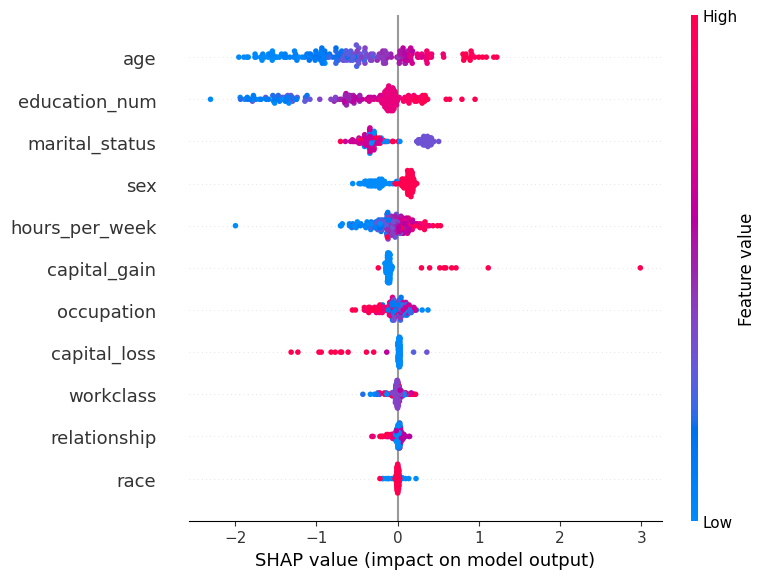

In [19]:
# SHAP summary plot (beeswarm) for rejected cases
shap.summary_plot(shap_values, X_rejected_sample, feature_names=feature_cols, show=True, max_display=11)

In [20]:
# Sensitive attribute importance
print("Sensitive attribute SHAP importance:")
for attr in ["sex", "age", "race"]:
    rank = list(shap_importance.index).index(attr) + 1
    print(f"  {attr}: rank {rank}, mean |SHAP| = {shap_importance[attr]:.4f}")

Sensitive attribute SHAP importance:
  sex: rank 4, mean |SHAP| = 0.1888
  age: rank 1, mean |SHAP| = 0.7063
  race: rank 11, mean |SHAP| = 0.0163


## 5. DiCE Counterfactual Explanations

DiCE generates diverse counterfactual examples showing the minimal changes needed to flip a rejection into an approval. We analyze which features DiCE modifies most frequently.

In [21]:

X_train_f = X_train.copy().astype("float64")
y_train_f = y_train.copy().astype("float64")
cf_sample  = X_test_rejected.head(30).copy().astype("float64")


all_features_as_continuous = feature_cols  # kategorikler de sayısal olduğu için


train_df = X_train_f.copy()
train_df["income"] = y_train_f.values

d = dice_ml.Data(
    dataframe=train_df,
    continuous_features=all_features_as_continuous,
    outcome_name="income"
)
m   = dice_ml.Model(model=model, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")


print(f"Generating counterfactuals for {len(cf_sample)} rejected instances...")
dice_results = exp.generate_counterfactuals(
    cf_sample,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary="all",
    random_seed=42
)


changed_features = {col: 0 for col in feature_cols}
total_cfs = 0

for i in range(len(cf_sample)):
    try:
        cf_df    = dice_results.cf_examples_list[i].final_cfs_df
        original = cf_sample.iloc[i]
        for _, cf_row in cf_df.iterrows():
            total_cfs += 1
            for col in feature_cols:
                if col in cf_row.index and cf_row[col] != original[col]:
                    changed_features[col] += 1
    except Exception:
        continue

change_freq = (pd.Series(changed_features) / total_cfs).sort_values(ascending=False)
print(f"\nTotal counterfactuals generated: {total_cfs}")
print("\nFeature modification frequency:")
print(change_freq.to_string())

Generating counterfactuals for 30 rejected instances...


100%|██████████| 30/30 [00:03<00:00,  9.69it/s]


Total counterfactuals generated: 90

Feature modification frequency:
capital_gain      0.455556
age               0.211111
education_num     0.200000
hours_per_week    0.155556
relationship      0.144444
sex               0.122222
marital_status    0.122222
occupation        0.111111
workclass         0.077778
capital_loss      0.066667
race              0.033333


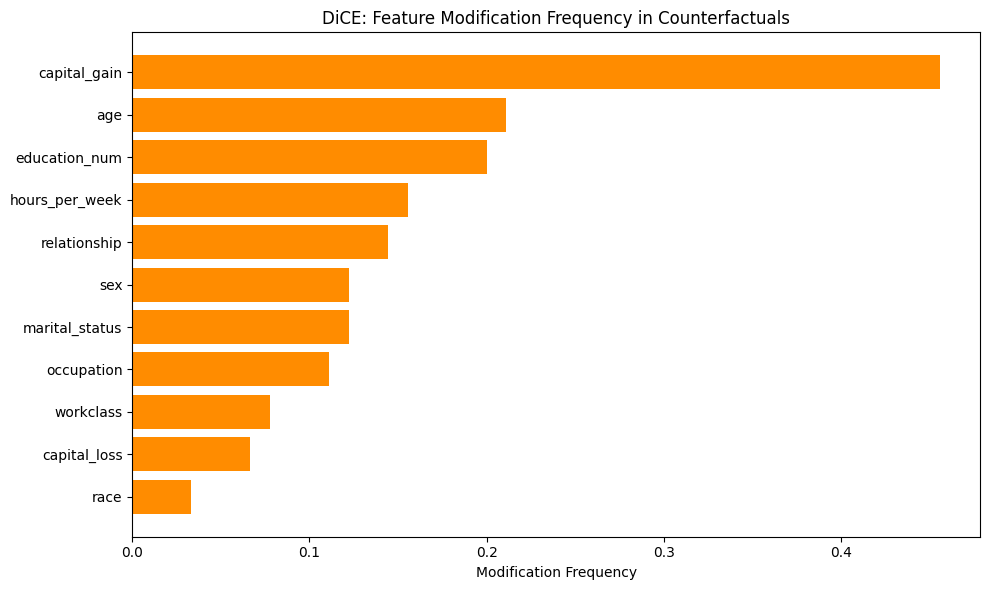

Sensitive attribute modification frequency:
  sex: rank 6, freq = 0.122
  age: rank 2, freq = 0.211
  race: rank 11, freq = 0.033


In [22]:
# DiCE bar plot
top_n = min(11, len(feature_cols))
top_dice = change_freq.head(top_n)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_dice)), top_dice.values[::-1], color="darkorange")
plt.yticks(range(len(top_dice)), top_dice.index[::-1])
plt.xlabel("Modification Frequency")
plt.title("DiCE: Feature Modification Frequency in Counterfactuals")
plt.tight_layout()
plt.show()

# Sensitive attribute modification
print("Sensitive attribute modification frequency:")
for attr in ["sex", "age", "race"]:
    freq = change_freq.get(attr, 0)
    rank = list(change_freq.index).index(attr) + 1 if attr in change_freq.index else "N/A"
    print(f"  {attr}: rank {rank}, freq = {freq:.3f}")

## 6. Comparison: SHAP vs DiCE

We compare the two methods by examining top-5 feature overlap and computing Spearman rank correlation.

In [23]:
# Top:5 feature comparison
shap_top5 = set(shap_importance.head(5).index)
dice_top5 = set(change_freq.head(5).index)
overlap = shap_top5 & dice_top5

print(f"SHAP top-5: {shap_top5}")
print(f"DiCE top-5: {dice_top5}")
print(f"Overlap: {overlap} ({len(overlap)}/5 features)")

# Spearman rank correlation
shap_ranks = shap_importance.rank(ascending=False)
dice_ranks = change_freq.reindex(shap_importance.index).rank(ascending=False)
correlation, p_value = spearmanr(shap_ranks, dice_ranks)
print(f"\nSpearman rank correlation: {correlation:.4f} (p = {p_value:.4f})")

SHAP top-5: {'sex', 'age', 'education_num', 'hours_per_week', 'marital_status'}
DiCE top-5: {'capital_gain', 'age', 'education_num', 'hours_per_week', 'relationship'}
Overlap: {'hours_per_week', 'age', 'education_num'} (3/5 features)

Spearman rank correlation: 0.6515 (p = 0.0299)


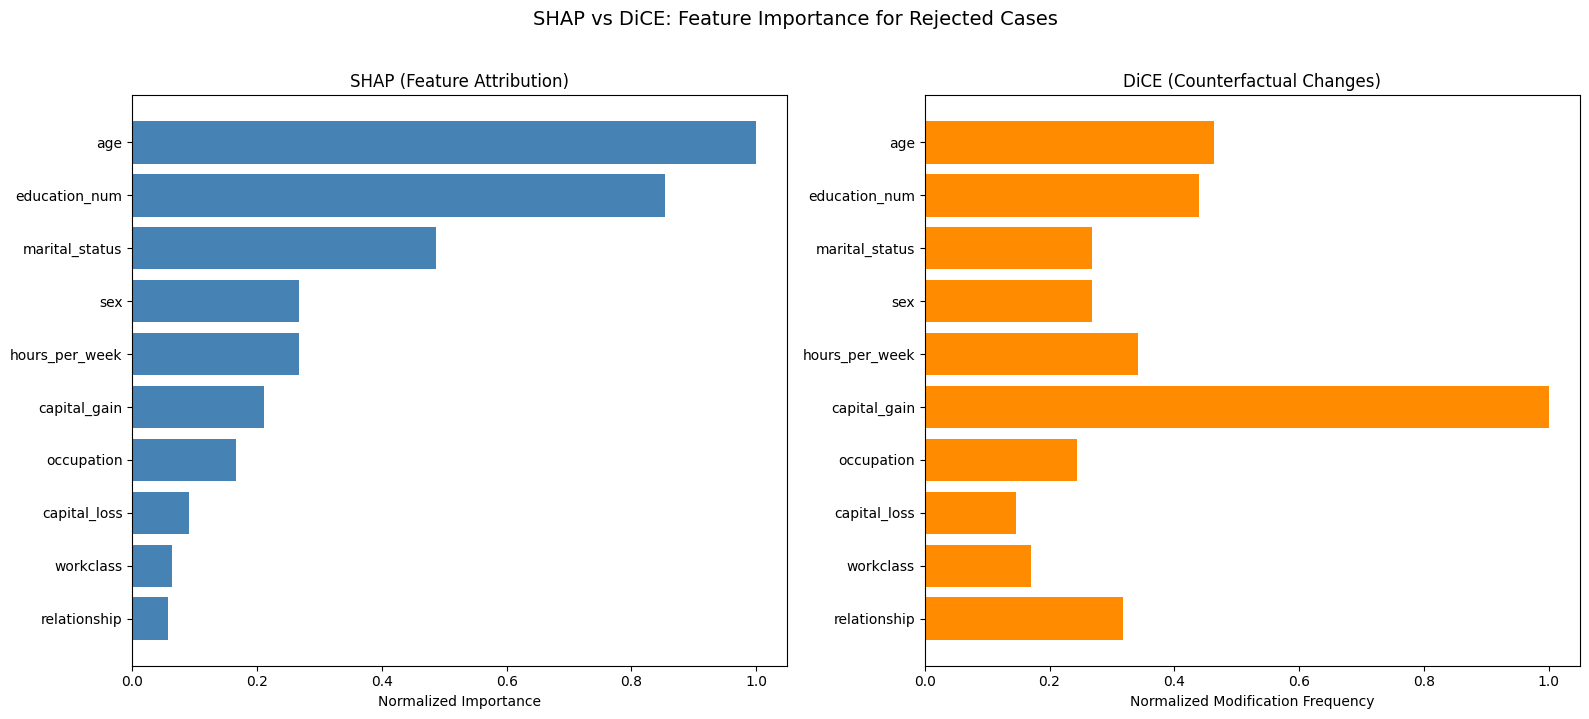

In [24]:
# Side by side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

shap_norm = shap_importance / shap_importance.max()
dice_norm = change_freq / change_freq.max() if change_freq.max() > 0 else change_freq
top_features = shap_importance.head(10).index.tolist()

shap_vals = [shap_norm[f] for f in top_features]
ax1.barh(range(len(top_features)), shap_vals[::-1], color="steelblue")
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features[::-1])
ax1.set_xlabel("Normalized Importance")
ax1.set_title("SHAP (Feature Attribution)")

dice_vals = [dice_norm.get(f, 0) for f in top_features]
ax2.barh(range(len(top_features)), dice_vals[::-1], color="darkorange")
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features[::-1])
ax2.set_xlabel("Normalized Modification Frequency")
ax2.set_title("DiCE (Counterfactual Changes)")

plt.suptitle("SHAP vs DiCE: Feature Importance for Rejected Cases", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Fairness Audit: Group-Level Analysis

We compare SHAP explanations across demographic groups (sex, age) to detect potential bias in feature attributions.

In [25]:
# Group-level SHAP analysis by sex
sex_values = X_rejected_sample["sex"].values
sex_le = label_encoders["sex"]
sex_labels = sex_le.inverse_transform([0, 1])

for sex_val in [0, 1]:
    mask = sex_values == sex_val
    if mask.sum() > 0:
        group_shap = np.abs(shap_values[mask]).mean(axis=0)
        group_importance = pd.Series(group_shap, index=feature_cols).sort_values(ascending=False)
        print(f"\nGroup: {sex_labels[sex_val]} (n={mask.sum()})")
        print(f"  Top-5 SHAP features: {list(group_importance.head(5).index)}")

# Age group analysis
age_median = X_rejected_sample["age"].median()
young_mask = X_rejected_sample["age"].values <= age_median
old_mask = ~young_mask

for label, mask in [("Young (<=median)", young_mask), ("Old (>median)", old_mask)]:
    if mask.sum() > 0:
        group_shap = np.abs(shap_values[mask]).mean(axis=0)
        group_importance = pd.Series(group_shap, index=feature_cols).sort_values(ascending=False)
        print(f"\nGroup: {label} (n={mask.sum()})")
        print(f"  Top-5 SHAP features: {list(group_importance.head(5).index)}")


Group: Female (n=77)
  Top-5 SHAP features: ['age', 'education_num', 'marital_status', 'sex', 'hours_per_week']

Group: Male (n=123)
  Top-5 SHAP features: ['age', 'education_num', 'marital_status', 'hours_per_week', 'capital_gain']

Group: Young (<=median) (n=104)
  Top-5 SHAP features: ['age', 'education_num', 'marital_status', 'sex', 'hours_per_week']

Group: Old (>median) (n=96)
  Top-5 SHAP features: ['education_num', 'age', 'marital_status', 'hours_per_week', 'sex']


## Summary

This analysis demonstrates how SHAP and DiCE provide complementary perspectives on rejected loan decisions. SHAP identifies which features most strongly drive the rejection (attribution), while DiCE reveals the minimal changes needed to overturn it (actionability). The partial overlap in top features validates that both methods capture real patterns, while their differences highlight distinct aspects of the model's decision boundary.